First 5 Rows of Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


/tmp/ipykernel_1747/2087004578.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species', data=data, palette='viridis')


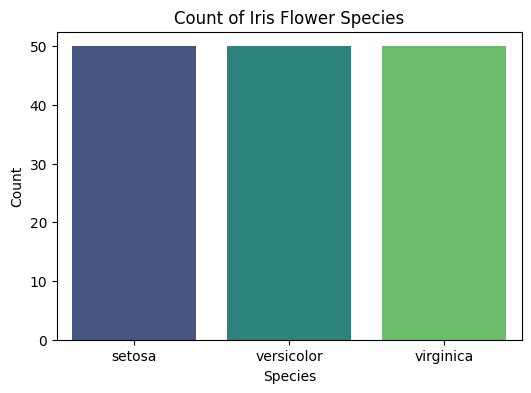

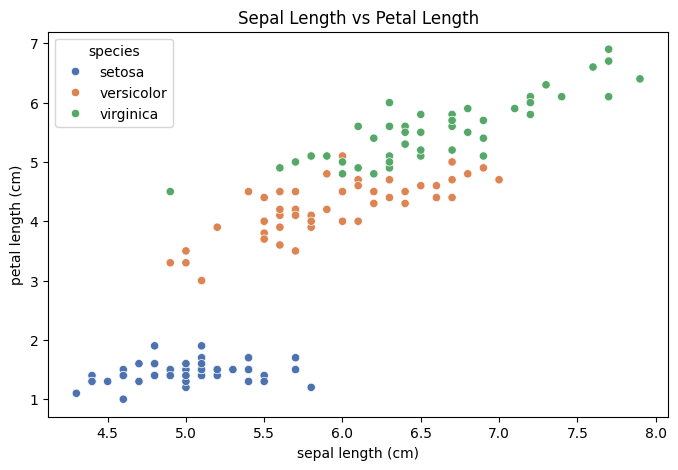


Model Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



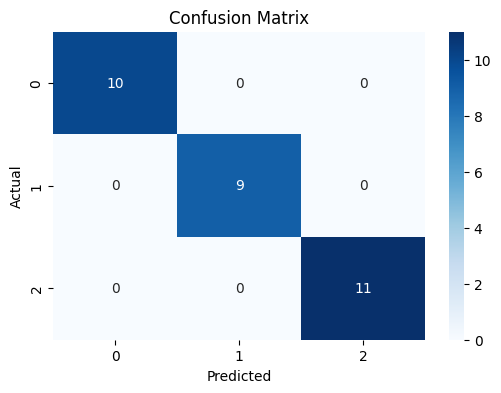


Predicted Species: setosa


In [ ]:
# IRIS FLOWER CLASSIFICATION WITH PYTHON

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Iris Dataset
iris = load_iris()

# Create DataFrame
data = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add Target Column
data['species'] = iris.target

# Convert Target Numbers into Species Names
data['species'] = data['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

# Display First 5 Rows
print("First 5 Rows of Dataset:")
print(data.head())

# -----------------------------
# GRAPH 1 - Species Count
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='species', data=data, palette='viridis')
plt.title("Count of Iris Flower Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

# -----------------------------
# GRAPH 2 - Sepal Length vs Petal Length
# -----------------------------
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=data['sepal length (cm)'],
    y=data['petal length (cm)'],
    hue=data['species'],
    palette='deep'
)
plt.title("Sepal Length vs Petal Length")
plt.show()

# Features and Target
X = iris.data
y = iris.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

# Make Predictions
predictions = model.predict(X_test)

# Model Accuracy
accuracy = accuracy_score(y_test, predictions)

print("\nModel Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)

# -----------------------------
# GRAPH 3 - Confusion Matrix
# -----------------------------
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# Predict New Flower
# -----------------------------
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

species_name = iris.target_names[prediction[0]]

print("\nPredicted Species:", species_name)